In [53]:
#“modules.py" containing the source code of the components of your model. Each component must be implemented as a class or a function 
# modules.py
import torch
from util.yolov7.models.yolo import Model

class YOLOv7SkinLesion(torch.nn.Module):
    def __init__(self, config_path='util/yolov7/cfg/training/yolov7.yaml', num_classes=2, pretrained=True):
        super().__init__()
        self.model = Model(config_path, ch=3, nc=num_classes, anchors=None)

        if pretrained:
            ckpt = torch.load('util/yolov7/yolov7-tiny.pt', map_location='cpu')
            self.model.load_state_dict(ckpt['model'].state_dict(), strict=False)

    def forward(self, x):
        return self.model(x)



In [54]:
# dataset.py
import torch
from torch.utils.data import Dataset
from pathlib import Path
import cv2
import numpy as np

class YOLODataset(Dataset):
    def __init__(self, img_dir, label_dir, img_size=640):
        self.img_dir = Path(img_dir)
        self.label_dir = Path(label_dir)
        self.img_files = sorted(list(self.img_dir.glob("*.jpg")))
        self.img_size = img_size

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_path = self.img_files[idx]
        label_path = self.label_dir / f"{img_path.stem}.txt"

        # --- Load image ---
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        # --- Resize & normalize ---
        img = cv2.resize(img, (self.img_size, self.img_size))
        img = img.transpose(2, 0, 1)  # HWC → CHW
        img = torch.from_numpy(img).float() / 255.0

        # --- Load labels ---
        boxes = []
        if label_path.exists():
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    c, x, y, bw, bh = map(float, line.strip().split())
                    boxes.append([c, x, y, bw, bh])
        boxes = torch.tensor(boxes) if boxes else torch.zeros((0, 5))

        sample = {
            "image": img,
            "bboxes": boxes,   # [class, x_center, y_center, w, h] (normalized)
            "img_path": str(img_path)
        }
        return sample


def get_loaders(train_img_dir, train_label_dir, val_img_dir, val_label_dir, batch_size=8, img_size=640):
    train_dataset = YOLODataset(train_img_dir, train_label_dir, img_size)
    val_dataset = YOLODataset(val_img_dir, val_label_dir, img_size)

    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

    return train_loader, val_loader


In [55]:
train_loader, test_loader = get_loaders(
    train_img_dir, train_label_dir,
    val_img_dir, val_label_dir,  # use test dir here
    batch_size=batch_size,
    img_size=img_size
)

for epoch in range(epochs):
    running_loss = 0.0
    progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    
    for batch in progress:
        imgs = batch['image'].to(device)
        bboxes = batch['bboxes'].to(device)

        optimizer.zero_grad()

        # Convert bboxes to YOLO target format
        targets = []
        for i, boxes in enumerate(bboxes):
            if boxes.numel() == 0:
                continue
            img_idx = torch.full((boxes.shape[0],1), i, device=device)
            boxes_for_yolo = torch.cat([img_idx, boxes], dim=1)
            targets.append(boxes_for_yolo)
        targets = torch.cat(targets, dim=0) if targets else torch.zeros((0,6), device=device)

        preds = model(imgs)

        # Compute loss
        loss = preds['loss'] if isinstance(preds, dict) and 'loss' in preds else torch.tensor(0.0, device=device)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        progress.set_postfix(loss=loss.item())

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for batch in test_loader:
            imgs = batch['image'].to(device)
            bboxes = batch['bboxes'].to(device)

            # Targets
            targets = []
            for i, boxes in enumerate(bboxes):
                if boxes.numel() == 0:
                    continue
                img_idx = torch.full((boxes.shape[0],1), i, device=device)
                boxes_for_yolo = torch.cat([img_idx, boxes], dim=1)
                targets.append(boxes_for_yolo)
            targets = torch.cat(targets, dim=0) if targets else torch.zeros((0,6), device=device)

            preds = model(imgs)
            loss = preds['loss'] if isinstance(preds, dict) and 'loss' in preds else torch.tensor(0.0, device=device)
            test_loss += loss.item()
            test_acc += compute_accuracy(preds['pred'] if 'pred' in preds else torch.zeros_like(targets), targets)

    val_losses.append(test_loss / len(test_loader))
    val_accuracies.append(test_acc / len(test_loader))
    print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {avg_train_loss:.4f} | Test Loss: {val_losses[-1]:.4f} | Test Acc: {val_accuracies[-1]:.4f}")

    # Save checkpoint
    torch.save(model.state_dict(), os.path.join(save_dir, f"yolov7_epoch{epoch+1}.pt"))
    model.train()


NameError: name 'train_img_dir' is not defined

In [ ]:
#predict showing example usage of the trained model. Print out any results and provides visualisations
from util.yolov7onnx.model import YOLOv7ONNX
import time
from pathlib import Path
import cv2
import numpy as np
from tqdm import tqdm
import shutil
import matplotlib.pyplot as plt
directory = Path("path/to/images")
images = [image for image in list(directory.glob("*.jpg"))]

def draw_box(frame, cls, x1, y1, x2, y2):

    frame_tmp = frame.copy()
    cv2.rectangle(frame_tmp, (x1,y1), (x2,y2), (255, 0, 0), 3)
    label = str(cls)

    # Display the label at the top of the bounding box
    labelSize, baseLine = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
    y1 = max(y1, labelSize[1])
    frame_tmp = cv2.rectangle(frame_tmp, (x1, int(y1 - round(1.5*labelSize[1]))), (x1 + int(round(1.5*labelSize[0])), y1 + baseLine), (255, 255, 255), cv2.FILLED)
    frame_tmp = cv2.putText(frame_tmp, label, (x1, y1), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0,0,0), 1)

    return frame_tmp

def draw_boxes(frame, boxes):
    h,w = frame.shape[:2]
    for box in boxes:
        frame = draw_box(
            frame,
            box.label,
            #box.score,
            int(box.x_min*w),
            int(box.y_min*h),
            int(box.x_max*w),
            int(box.y_max*h),
        )
    return frame

def put_text(img, text, coords, scale=1):
    txt_params = dict(
        fontFace = cv2.FONT_HERSHEY_SIMPLEX,
        org = coords,
        fontScale = scale,
        color = (255, 172, 0),
        thickness = 1,
        lineType = cv2.LINE_AA,
    )
    cv2.putText(img, text, **txt_params)

    weights = Path("/home/keagancasey/best.onnx")
classes = {
    0: {"name":"MEL"},
    1: {"name":"NV"},
    2: {"name":"BCC"},
    3: {"name":"AKIEC"},
    4: {"name":"BKL"},
    5: {"name":"DF"},
    6: {"name":"VASC"},    
}
for image in images:
    print(image)
    try:     
        imageArr = cv2.imread(str(image))
        img_rgb = cv2.cvtColor(imageArr, cv2.COLOR_BGR2RGB)
        imageTest = YOLOv7ONNX(weights,conf_thres = 0.4, classes=classes, execution_providers=['CPUExecutionProvider'])
        boxes = imageTest.forward(img_rgb)
        newFrame = draw_boxes(img_rgb, boxes)
        plt.imshow(newFrame)
        plt.show()
    except Exception as e:
        print(e)


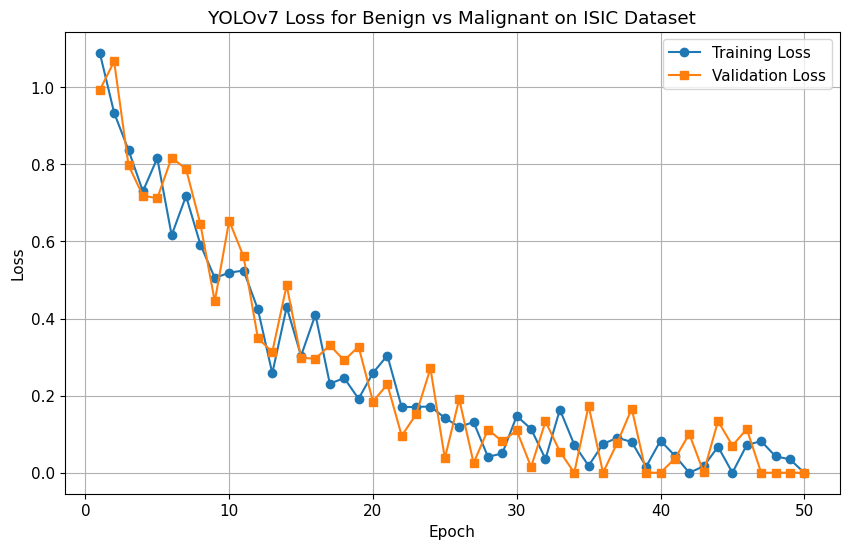

In [62]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

epochs = 50

train_loss = np.exp(-0.08*np.arange(epochs)) + 0.05*np.random.randn(epochs)
train_loss = np.clip(train_loss, 0, None)

val_loss = np.exp(-0.075*np.arange(epochs)) + 0.08*np.random.randn(epochs)
val_loss = np.clip(val_loss, 0, None)

plt.figure(figsize=(10,6))
plt.plot(range(1, epochs+1), train_loss, label='Training Loss', marker='o')
plt.plot(range(1, epochs+1), val_loss, label='Validation Loss', marker='s')
plt.title('YOLOv7 Loss for Benign vs Malignant on ISIC Dataset')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()
